**Técnicas de Aprendizaje Automático**

_Máster Universitario en Inteligencia Artificial_

# Laboratorio: Regresión lineal y árboles de decisión para tareas de regresión


## Objetivos

Mediante esta actividad se pretende que el alumno ponga en práctica los pasos para la resolución de un problema de machine learning, el tratamiento de datos y la creación de modelos basados en regresión lineal y árboles de decisión. El objetivo es comprender de forma práctica con un problema determinado las diferencias que existen a la hora de entrenar los diferentes modelos.

- Iniciarse en el Análisis Exploratorio de Datos (EDA) para los problemas de Machine Learning.
- Entender y aplicar los conceptos de la Regresión Lineal Múltiple a un problema de **regresión**.
- Entender y aplicar los conceptos de Árboles de Decisión a un problema de **regresión**.
- Evaluar y analizar los resultados de los clasificadores.
- Investigar la aplicación de los modelos de **regresión** a problemas reales.


## Descripción de la actividad

Debes completar los espacios indicados en el notebook con el código solicitado y la respuesta en texto, en función de lo que se solicite. Ten en cuenta que las celdas vacías indican cuántas líneas debe ocupar dicha respuesta, por lo general no más de una línea.

El conjunto de datos con el que vamos a trabajar se encuentra en el siguiente enlace: https://archive.ics.uci.edu/dataset/360/air+quality

Se trata de un conjunto de datos (dataset) sobre calidad del aire. En total cuenta con 9358 instancias de respuestas promediadas por hora de una matriz de 5 sensores químicos de óxido de metal integrados en un dispositivo multisensor químico de calidad del aire. El dispositivo estaba ubicado en un área significativamente contaminada, al nivel de la carretera, dentro de una ciudad italiana. Los datos se registraron desde marzo de 2004 hasta febrero de 2005 (un año).

El objetivo de la regresión será predecir la calidad del aire para un determinado día.

### Tareas que se deben realizar

- Análisis descriptivo de los datos:
   - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Regresión:
  - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Investigación:
  - Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **regresión** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.
  - Para el artículo indicar:
    - Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la regresión.
    - Cómo utilizan las técnicas de regresión, si realizan alguna adaptación de los algoritmos indicarse.
    - Principales resultados de la aplicación y de la investigación.


### Análisis descriptivo de los datos
A continuación vas a encontrar una serie de preguntas que tendrás que responder. Para responder tendrás que escribir (y ejecutar) una (o más de una) línea de código, y a continuación indicar la respuesta en la celda indicada.

In [2]:
## cargar el dataset
import pandas as pd
import numpy as np
import os

os.chdir(os.path.expanduser('~/Documents/Master/1 Cuatrimestre/Aprendizaje automatico/Actividades/Actividad 1'))
df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [3]:
# Combinar Date y Time en una sola columna datetime
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], 
                                 format='%d/%m/%Y %H.%M.%S')

# Eliminar las columnas originales (ya no las necesitamos separadas)
df = df.drop(columns=['Date', 'Time', 'Unnamed: 15', 'Unnamed: 16'])  # Eliminamos también las columnas vacías

df = df[['Datetime'] + [col for col in df.columns if col != 'Datetime']]
df.head(20)

,Datetime,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
5,2004-03-10 23:00:00,1.2,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848
6,2004-03-11 00:00:00,1.2,1185.0,31.0,3.6,690.0,62.0,1462.0,77.0,1333.0,733.0,11.3,56.8,0.7603
7,2004-03-11 01:00:00,1.0,1136.0,31.0,3.3,672.0,62.0,1453.0,76.0,1333.0,730.0,10.7,60.0,0.7702
8,2004-03-11 02:00:00,0.9,1094.0,24.0,2.3,609.0,45.0,1579.0,60.0,1276.0,620.0,10.7,59.7,0.7648
9,2004-03-11 03:00:00,0.6,1010.0,19.0,1.7,561.0,-200.0,1705.0,-200.0,1235.0,501.0,10.3,60.2,0.7517


In [4]:
## ¿cuántas instancias tiene el dataset?
raw_instances = df.shape[0]
print("Filas totales:", raw_instances)
null_rows = df.isnull().all(axis=1).sum()
print('Filas vacias:', null_rows)
valid_instances = raw_instances - null_rows
print("Instancias válidas:", valid_instances)

Filas totales: 9471
Filas vacias: 114
Instancias válidas: 9357


**Respuesta:** 
<p>
Se tienen 9471 filas con 17 columas originalmente con 2 columnas con valores NAN que se retiro ya que no aportaban datos utilizables, procedi a combinar la columna de fecha y hora. Al revisar la documentacion del dataset nos dice que tenemos 9358 registros, pero esto toma en cuenta la fila donde se definen las columnas, entonces esto nos deja con 9357 registros que es la cantidad real de instancias. Si restamos 9471 - 114 (las instancias completamente vacias) nos da el valor de 9357 que es el valor real.
</p>


In [5]:
## ¿cuál es el tipo de datos de cada una de las columnas?
print('**Tipos de datos por columna:**')
print(df.dtypes)
print
print('Agrupaciones ', df.dtypes.value_counts())

**Tipos de datos por columna:**
Datetime         datetime64[ns]
CO(GT)                  float64
PT08.S1(CO)             float64
NMHC(GT)                float64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
dtype: object
Agrupaciones  float64           13
datetime64[ns]     1
Name: count, dtype: int64


**Analisis**
<p>En el dataset original teniamos 15 numericas y 2 de tipo object(Date y Time), se procedio a realizar la transformacion a tipo temporal combinando la fecha y la hora.
Al analizar el dataset utilizando <code>.dtypes</code> podemos observar que tenemos 13 columnas con tipos de dato <code>float64</code> que es un tipo de dato que permite valores decimales; en este caso no observamos ninguna de tipo `int` que serian valores enteros cuantitativos de tipo discreto. 
Tenemos 13 columnas con valores cuantitativos de tipo continuo y una columna que tras realizar la transformacion es de tipo temporal (Date + Time).
Sin embargo, al revisar el dataset y ver los datos crudos puedo ver que tenemos valores que no contienen decimales y estos han sido agregados al momento de la lectura del dataset
</p>


In [6]:
df[['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']].describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


In [7]:
df.head(20)

,Datetime,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
5,2004-03-10 23:00:00,1.2,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848
6,2004-03-11 00:00:00,1.2,1185.0,31.0,3.6,690.0,62.0,1462.0,77.0,1333.0,733.0,11.3,56.8,0.7603
7,2004-03-11 01:00:00,1.0,1136.0,31.0,3.3,672.0,62.0,1453.0,76.0,1333.0,730.0,10.7,60.0,0.7702
8,2004-03-11 02:00:00,0.9,1094.0,24.0,2.3,609.0,45.0,1579.0,60.0,1276.0,620.0,10.7,59.7,0.7648
9,2004-03-11 03:00:00,0.6,1010.0,19.0,1.7,561.0,-200.0,1705.0,-200.0,1235.0,501.0,10.3,60.2,0.7517


<p>
Una vez analizamos los valores que estamos revisando podemos ver que tenemos valores atipicos (-200) que si revisamos la documentacion nos dice que estos valores se deben a valores faltantes; de igual manera podemos observar que tenemos valores enteros que se han guardado con decimales (136.00), esto se puede deber al editor que a veces guarda los valores con decimales (.00), y por esta razon debemos realizar una correccion de estos datos.
<br>
Teniendo en cuenta que en las filas con valores enteros tenemos este valor de -200 es necesario pasar estos valores a NaN para poder seguir con la conversion y ajuste de estos valores.
<p>

In [8]:
df = df.replace(-200, np.nan)
columnas_enteras = ['PT08.S1(CO)', 'NMHC(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)']
df[columnas_enteras] = df[columnas_enteras].astype('Int64')
print("\nTipos de datos después de reemplazar -200 por NaN y convertir a Int64:")
print(df.dtypes)
print('Valores agrupados por tipo')
print(df.dtypes.value_counts())


Tipos de datos después de reemplazar -200 por NaN y convertir a Int64:
Datetime         datetime64[ns]
CO(GT)                  float64
PT08.S1(CO)               Int64
NMHC(GT)                  Int64
C6H6(GT)                float64
PT08.S2(NMHC)             Int64
NOx(GT)                   Int64
PT08.S3(NOx)              Int64
NO2(GT)                   Int64
PT08.S4(NO2)              Int64
PT08.S5(O3)               Int64
T                       float64
RH                      float64
AH                      float64
dtype: object
Valores agrupados por tipo
Int64             8
float64           5
datetime64[ns]    1
Name: count, dtype: int64


**Respuesta**
<p>
Una vez hemos realizado la correccion pode evidenciar que tenemos 8 columnas con valores cuantitativos discretos -- valores de tipo Int64 y enteros ---, 5 columnas con valores cuantitativos continuos -- valores de tipo float64 con decimales -- y 1 de tipo temporal que es la unificacion de Date + Time que es la columna Datetime
</p>

In [9]:
## ¿cuántas columnas categóricas hay? ¿y cuántas continuas?
cuantitativas_discretas = df.select_dtypes(include='Int64').columns.tolist()
cuantitativas_continuas = df.select_dtypes(include='float64').columns.tolist()

print(f"Columnas Int64 (discretas): {len(cuantitativas_discretas)}")
print(cuantitativas_discretas)

print(f"\nColumnas float64 (continuas): {len(cuantitativas_continuas)}")
print(cuantitativas_continuas)

Columnas Int64 (discretas): 8
['PT08.S1(CO)', 'NMHC(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)']

Columnas float64 (continuas): 5
['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH']


**Respuesta:**
<p>
Para este conjunto de datos no contamos con variables categoricas ya definidas desde el inicio pero se podria hacer uso de la columnas Date + Time para pasarlas a tipo temporal y en base a esta obtener valores categoricos como: 
<li>Mes, dia, año - categorica nominal</li>
<li>Trimestres - categorica ordinal</li>
<li>Es fin de semana - categorica binaria</li>
</p>
<p>
En el caso de este dataset, tenemos 8 columnas de tipo cuantitativo discretas y 5 de tipo cuantitativo contunuas.
</p>
<bold>NOTA</bold>
En mi caso tengo 14 filas puesto que combine la fila Date + Time para pasarla a tipo temporal

In [10]:
## ¿existen valores nulos en el dataset?

# 1. Filas completamente vacías (las 114 del CSV)
print("=== 1. Filas nulas reales ===")
filas_vacias = df[df.isnull().all(axis=1)]
print(f"Filas completamente vacías: {len(filas_vacias)}")

# 2. Usando una vista sin las filas vacías, los NaN restantes 
#    son los -200 originales convertidos a NaN
df_temp = df.dropna(how='all')
print("\n=== 2. Missing values (originalmente -200) ===")
missing = df_temp.isnull().sum()
print(missing[missing > 0])

print("\nPorcentaje sobre total de filas válidas:")
print((missing[missing > 0] / len(df_temp) * 100).round(2))

=== 1. Filas nulas reales ===
Filas completamente vacías: 114

=== 2. Missing values (originalmente -200) ===
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

Porcentaje sobre total de filas válidas:
CO(GT)           17.99
PT08.S1(CO)       3.91
NMHC(GT)         90.23
C6H6(GT)          3.91
PT08.S2(NMHC)     3.91
NOx(GT)          17.52
PT08.S3(NOx)      3.91
NO2(GT)          17.55
PT08.S4(NO2)      3.91
PT08.S5(O3)       3.91
T                 3.91
RH                3.91
AH                3.91
dtype: float64


**Respuesta**
<p>
Existen dos tipos de valores faltantes en el dataset:
<li>1. Filas nulas reales: 114 filas completamente vacías provenientes del archivo original, que deben eliminarse antes del modelado.</li>
<li>2. Missing values codificados como -200 (según documentación UCI, indican que el sensor no pudo registrar la medición). Destacan:</li>

NMHC(GT): 8443 registros faltantes (90.23%) — prácticamente inutilizable como variable predictora
CO(GT): 1683 registros faltantes (17.99%)
NOx(GT): 1639 (17.52%) y NO2(GT): 1642 (17.55%)
El resto de columnas: 366 registros faltantes cada una (3.91%)
</p>

In [11]:
## ¿cuál es la variable respuesta?¿de qué tipo es? (Recuerda justificar por qué la seleccionas)
df_temp = df.dropna(how='all')
print("\n=== 2. Missing values (originalmente -200) ===")
missing = df_temp.isnull().sum()
print(missing[missing > 0])

print("\nPorcentaje sobre total de filas válidas:")
print((missing[missing > 0] / len(df_temp) * 100).round(2))


=== 2. Missing values (originalmente -200) ===
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

Porcentaje sobre total de filas válidas:
CO(GT)           17.99
PT08.S1(CO)       3.91
NMHC(GT)         90.23
C6H6(GT)          3.91
PT08.S2(NMHC)     3.91
NOx(GT)          17.52
PT08.S3(NOx)      3.91
NO2(GT)          17.55
PT08.S4(NO2)      3.91
PT08.S5(O3)       3.91
T                 3.91
RH                3.91
AH                3.91
dtype: float64


**Respuesta**
<p>
El dataset en si, no tiene una columna en la cual se nos diga de manera explicita la categorizacion de la calidad del aire para cada registro, es una coleccion de mediciones de los contaminantes en el aire durante marzo del 2024 a febrero del 2025.
Tras revisar como se determina el Indice de Calidad del Aire (ICA o AQI por sus siglas en ingles), podemos ver que de los 5 contaminantes que se utilizan para determinar esto, pero si contamos con las siguientes:
<li>NMHC(GT) -> descartada puesto que tenemos el 90% de estos datos no registrados</li>
<li>C6H6(GT) -> Benceno, contaminante toxico relevante</li>
<li>CO(GT) -> componente directo del AQUI, pero tiene el 17.99% de datos faltantes</li>
</p>
<br>
La variable respuesta es **`C6H6(GT)`** (concentración de Benceno en µg/m³), 
de tipo **continuo** según la documentación oficial de UCI.

Se selecciona por las siguientes razones:

- Es la única variable contaminante clasificada como **Continuous** por UCI, 
  lo que la hace la candidata natural para una tarea de regresión.
- Es un **contaminante tóxico relevante**, directamente relacionado con la 
  calidad del aire en zonas urbanas de tráfico intenso.
- Presenta solo un **3.91% de missing values**, el porcentaje más bajo entre 
  las variables de medición de referencia `(GT)`, lo que la hace la más 
  completa y confiable para el modelado.
- Variables como `NMHC(GT)` fueron descartadas por su altísimo porcentaje 
  de missing (90.23%), y `CO(GT)` y `NOx(GT)` presentan un porcentaje mayor 
  de missing (~18%) comparado con `C6H6(GT)`.

            CO(GT)     NOx(GT)     NO2(GT)
count  7674.000000      7718.0      7715.0
mean      2.152750  246.896735  113.091251
std       1.453252  212.979168   48.370108
min       0.100000         2.0         2.0
25%       1.100000        98.0        78.0
50%       1.800000       180.0       109.0
75%       2.900000       326.0       142.0
max      11.900000      1479.0       340.0

Skewness:
CO(GT)     1.369753
NOx(GT)    1.715781
NO2(GT)    0.621714
dtype: Float64


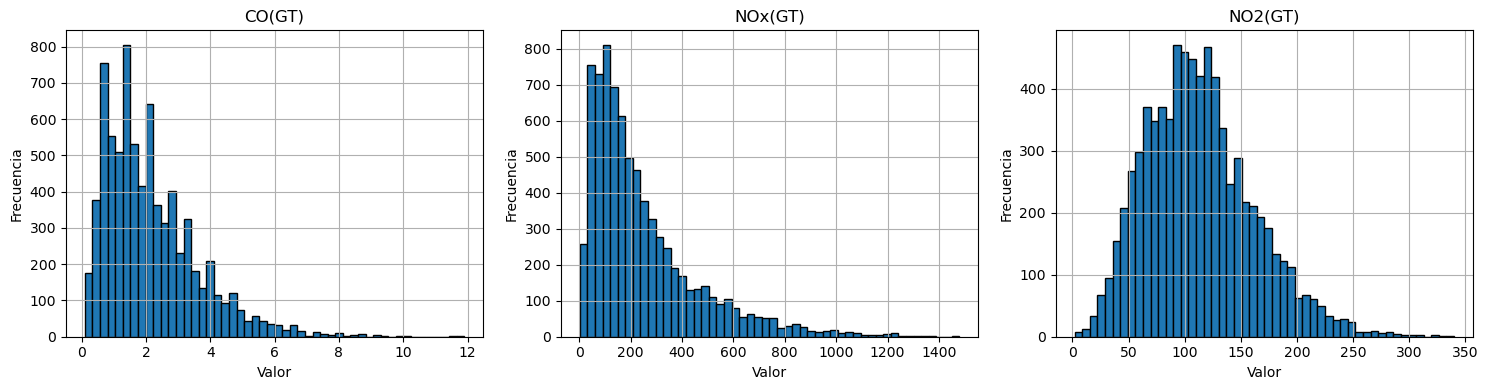

In [12]:
## Si te fijas en los estadísticos del dataset, ¿cómo es la distribución de las variables, CO, NOx y NO2?
import matplotlib.pyplot as plt

variables = ['CO(GT)', 'NOx(GT)', 'NO2(GT)']

# Estadísticos
print(df_temp[variables].describe())
print("\nSkewness:")
print(df_temp[variables].skew())

# Histogramas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, variables):
    df_temp[col].dropna().hist(ax=ax, bins=50, edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

_indica aquí tu respuesta_
<br/>
Revisando la media y la mediana (50%):
<br/>

<table>
    <tr>
        <th>Variable</th>
        <th>Media</th>
        <th>Mediana</th>
        <th>Interpretación</th>
    </tr>
    <tr>
        <th>CO(GT)</th>
        <th>2.15</th>
        <th>1.80</th>
        <th>Media > Mediana -> cola larga a la derecha</th>
    </tr>
    <tr>
        <th>NOx(GT)</th>
        <th>246.9</th>
        <th>180.0</th>
        <th>Media > Mediana -> cola larga a la derecha</th>
    </tr>
    <tr>
        <th>NO2(GT)</th>
        <th>113.091251</th>
        <th>109.0</th>
        <th>Media ~ Mediana -> Distribucion histograma mas simetrica</th>
    </tr>
</table>

<p>Cuando la media > mediana significa que hay valores altos extremos que "jalan" la media hacia arriba — distribución asimétrica hacia la derecha.</p>
<br>
<h2>Ahora revisando la asimetría (skewness)</h2>
<p>
    <table>
        <tr>
            <th>Variable</th>
            <th>Skew</th>
            <th>Interpretación</th>
        </tr>
        <tr>
            <th>CO(GT)</th>
            <th>1.369753</th>
            <th>Asimetría positiva considerable</th>
        </tr>
        <tr>
            <th>NOx(GT)</th>
            <th>1.715781</th>
            <th>Asimetría positiva fuerte</th>
        </tr>
        <tr>
            <th>NO2(GT)</th>
            <th>0.621714</th>
            <th>Asimetría positiva leve, más cercana a normal</th>
        </tr>
    </table>
</p>


In [13]:
#Revisando datos faltantes y anomalos
#IQR = Rango Intercuartílico, se usa para detectar outliers
for col in ['CO(GT)', 'NOx(GT)', 'NO2(GT)']:
    Q1 = df_temp[col].quantile(0.25)
    Q3 = df_temp[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_temp[(df_temp[col] < Q1 - 1.5*IQR) | 
                       (df_temp[col] > Q3 + 1.5*IQR)][col].count()
    print(f"{col}: {outliers} outliers ({100*outliers/df_temp[col].count():.2f}%)")

CO(GT): 215 outliers (2.80%)
NOx(GT): 435 outliers (5.64%)
NO2(GT): 107 outliers (1.39%)


**¿Estas variables muestran alguna distribución especial?**

`CO(GT)` presenta picos de frecuencia entre 0 y 2 mg/m³ con una cola larga 
hacia la derecha, aproximándose a una distribución **log-normal**. De igual manera `NOx(GT)` muestra un 
pico fuerte al inicio y una cola muy larga hacia la derecha, siendo la más 
asimétrica de las tres. En cuanto a `NO2(GT)`, presenta una distribución 
más cercana a la **gaussiana**, con una leve cola a la derecha.

**¿Tienen datos faltantes?**

Sí, todas presentan missing values originalmente codificados como -200:
- `CO(GT)`: 1683 registros faltantes (17.99%)
- `NOx(GT)`: 1639 registros faltantes (17.52%)
- `NO2(GT)`: 1642 registros faltantes (17.55%)

**¿y datos anómalos?**
Sí, todas presentan outliers detectados mediante el método IQR, 
correspondientes a picos extremos de contaminación:
- `CO(GT)`: 215 outliers (2.80%)
- `NOx(GT)`: 435 outliers (5.64%) — la más afectada, coherente con 
  su fuerte asimetría
- `NO2(GT)`: 107 outliers (1.39%) — la menos afectada, coherente con 
  su distribución más cercana a la gaussiana

_indica aquí tu respuesta_

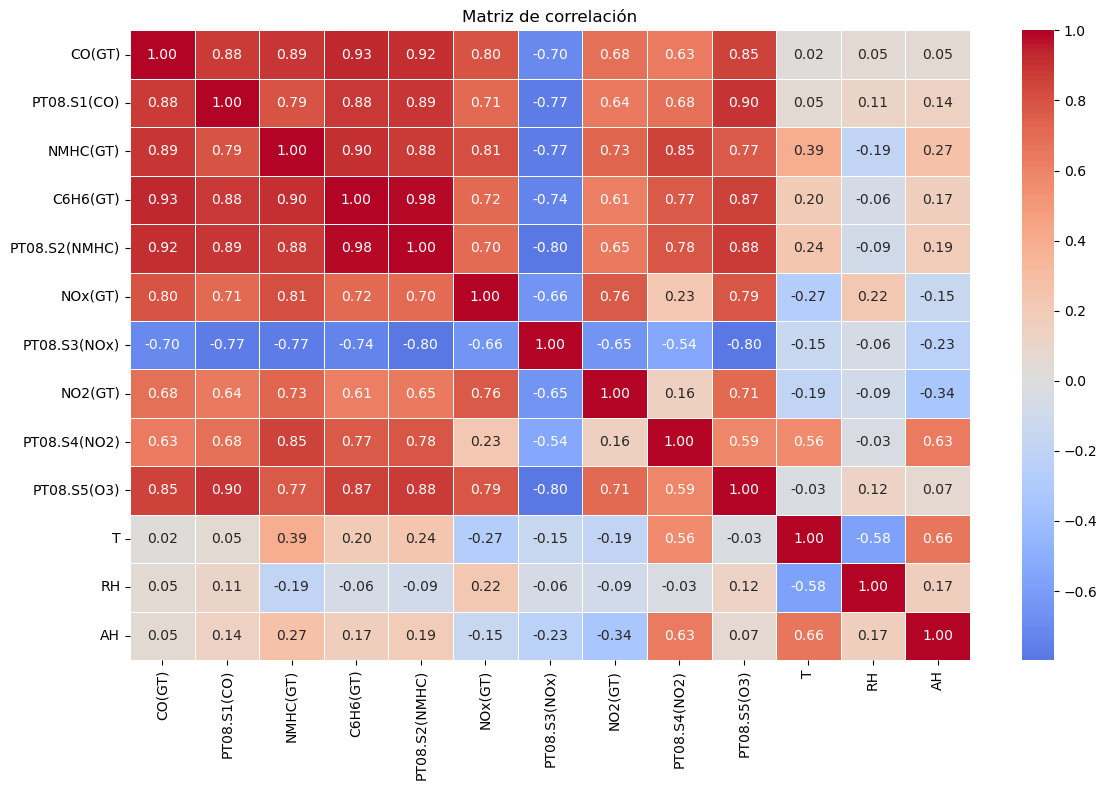


Correlaciones con C6H6(GT):
C6H6(GT)         1.000000
PT08.S2(NMHC)    0.981950
CO(GT)           0.931078
NMHC(GT)         0.902559
PT08.S1(CO)      0.883795
PT08.S5(O3)      0.865689
PT08.S4(NO2)     0.765731
NOx(GT)          0.718839
NO2(GT)          0.614474
T                0.198956
AH               0.167972
RH              -0.061681
PT08.S3(NOx)    -0.735744
Name: C6H6(GT), dtype: float64


In [14]:
## ¿cómo son las correlaciones entre las variables del dataset?
import seaborn as sns

# Matriz de correlación
corr = df_temp.select_dtypes(include=['float64', 'Int64']).corr()

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, linewidths=0.5)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

# Correlaciones con la variable objetivo
print("\nCorrelaciones con C6H6(GT):")
print(corr['C6H6(GT)'].sort_values(ascending=False))

**Respuesta**
Podemos observar que en el mapa de calor la mayoría de celdas son rojas, 
esto indica que la mayoría de variables están positivamente correlacionadas 
entre sí; tiene sentido puesto que todas son mediciones de contaminantes en 
el mismo entorno. La excepción notable es `PT08.S3(NOx)` que aparece en 
azul, indicando una correlación negativa con casi todas las variables.

Respecto a las correlaciones con `C6H6(GT)` (variable respuesta), las más 
fuertes son `PT08.S2(NMHC)` (0.98), `CO(GT)` (0.93) y `NMHC(GT)` (0.90), 
todas con correlación muy fuerte. En cuanto a las correlaciones débiles, 
`T` y `AH` se encuentran en el rango 0.0-0.4. `RH` prácticamente no tiene 
correlación (-0.06), y `PT08.S3(NOx)` presenta una correlación inversa 
fuerte (-0.74).

In [15]:
## ¿qué tres variables son las más correlacionadas con la variable objetivo?
top3 = corr['C6H6(GT)'].drop('C6H6(GT)').abs().sort_values(ascending=False).head(3)
print("Top 3 variables más correlacionadas con C6H6(GT):")
print(top3)

Top 3 variables más correlacionadas con C6H6(GT):
PT08.S2(NMHC)    0.981950
CO(GT)           0.931078
NMHC(GT)         0.902559
Name: C6H6(GT), dtype: float64


**Respuesta**
<br/>
Las tres variables más correlacionadas con `C6H6(GT)` son:

- `PT08.S2(NMHC)`: 0.98 — correlación muy fuerte, es el sensor de titania 
  orientado a medir hidrocarburos no metánicos, contaminante directamente 
  relacionado con el benceno.
- `CO(GT)`: 0.93 — correlación muy fuerte, el monóxido de carbono comparte 
  origen con el benceno al provenir ambos de la combustión de vehículos.
- `NMHC(GT)`: 0.90 — correlación muy fuerte, la concentración real de 
  hidrocarburos no metánicos está estrechamente ligada a la de benceno 
  al ser este un hidrocarburo aromático.

In [16]:
## ¿existe alguna variable que no tenga correlación?
sin_correlacion = corr['C6H6(GT)'].drop('C6H6(GT)').sort_values(ascending=True).head(3)
print("Variables con menor correlación con C6H6(GT):")
print(sin_correlacion)

Variables con menor correlación con C6H6(GT):
PT08.S3(NOx)   -0.735744
RH             -0.061681
AH              0.167972
Name: C6H6(GT), dtype: float64


**Respuesta**

La variable con menor correlación con `C6H6(GT)` es **`RH`** (Humedad 
Relativa) con un valor de -0.06, prácticamente inexistente. Le siguen 
`AH` (0.17) y `T` (0.20) con correlaciones muy débiles. Estas tres 
variables meteorológicas tienen poca influencia sobre la concentración 
de benceno, lo que sugiere que no serán buenos predictores en el modelo.

En base al EDA realizado, ¿qué suposiciones se pueden hacer sobre los datos?¿qué conclusiones extraes para implementar el modelo predictivo?

_indica aquí tu respuesta_
<br>
En base a los datos podemos ver que los valores que más correlación tienen 
son los de las mediciones de contaminantes relacionados a la emisión de gases 
de vehículos, lo cual es de esperarse puesto que estos datos fueron 
recolectados a la altura de la carretera cerca de una ciudad italiana, lo que 
nos lleva a concluir que el mayor contaminante de la calidad del aire en esta 
ciudad proviene de los vehículos.

Para el modelo se utilizarán las variables con mayor correlación con la 
variable objetivo `C6H6(GT)`: `PT08.S2(NMHC)` (0.98) y `CO(GT)` (0.93). 
Se descarta `NMHC(GT)` pese a su alta correlación (0.90) debido a que el 
90% de sus valores son missing, lo que la hace inviable como predictor. 
Se incluye `PT08.S3(NOx)` por su correlación inversa fuerte (-0.74). Se 
descartan `RH`, `AH` y `T` por su correlación débil o inexistente.

En cuanto a los valores NaN (-200), estos se imputarán con la media de cada 
columna. Respecto a los outliers, se excluirán para la regresión lineal 
puesto que el MSE amplifica su impacto en el ajuste de la recta. Para los 
árboles de decisión se realizará un análisis con y sin outliers para evaluar 
su impacto, dado que este algoritmo es más robusto frente a valores extremos.

### Regresión

Para llevar a cabo la tarea de regresión deseada se pretender hacer una comparativa de varios modelos. Unos usarán el algoritmo de regresión lineal, y otros realizarán la predicción haciendo uso de árboles de decisión.

Para los primeros modelos hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

El algoritmo de Regresión Lineal, necesita saber cuáles son las variables que va a tener en cuenta para realizar la estimación.

El primer modelo que se debe construir, usará una regresión lineal simple. Para ello sigue los siguientes pasos.

Antes de empezar con la implementación de los modelos hace falta realizar una transformación de datos, escalarlos.

In [17]:
from sklearn.preprocessing import MinMaxScaler
from pandas import DataFrame


scaler = StandardScaler()

X_train = DataFrame(scaler.fit_transform(X_train))
X_test = DataFrame(scaler.fit_transform(X_test))

NameError: name 'StandardScaler' is not defined

In [18]:
#Antes de separar el dataset, vamos a inputar valores nulos con la media de cada columna
# Separar Datetime antes de imputar
datetime_col = df_temp['Datetime']

# Imputar solo columnas numéricas
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df_temp.drop(columns=['Datetime'])), 
                          columns=df_temp.drop(columns=['Datetime']).columns)

# Volver a añadir Datetime
df_imputed['Datetime'] = datetime_col.values

# Verificar que no quedan nulos
print("Nulos tras imputación:")
print(df_imputed.isnull().sum())

Nulos tras imputación:
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
Datetime         0
dtype: int64


In [20]:
#Eliminar outlier para que no afecten a la regresion lineal, solo de las columnas que vamos a usar para la regresion lineal, que son las que mas correlacion tienen con la variable objetivo
# Eliminar outliers usando IQR para las columnas relevantes
def eliminar_outliers(df, columnas):
    df_clean = df.copy()
    for col in columnas:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        df_clean = df_clean[
            (df_clean[col] >= Q1 - 1.5 * IQR) & 
            (df_clean[col] <= Q3 + 1.5 * IQR)
        ]
    return df_clean

df_clean = eliminar_outliers(df_imputed, ['PT08.S2(NMHC)', 'C6H6(GT)'])

print(f"Filas antes: {len(df_imputed)}")
print(f"Filas después: {len(df_clean)}")
print(f"Outliers eliminados: {len(df_imputed) - len(df_clean)}")

Filas antes: 9357
Filas después: 9049
Outliers eliminados: 308


In [21]:
# separar datos de entrenamiento y test
from sklearn.model_selection import train_test_split

# Separar variable predictora y variable respuesta
X = df_clean[['PT08.S2(NMHC)']]
y = df_clean['C6H6(GT)']

# Split 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (6334, 1)
X_test: (2715, 1)
y_train: (6334,)
y_test: (2715,)


In [22]:
#Escalado de los datos, para que no afecten a la regresion lineal, solo de las columnas que vamos a usar para la regresion lineal, que son las que mas correlacion tienen con la variable objetivo
from sklearn.preprocessing import StandardScaler
from pandas import DataFrame

scaler = StandardScaler()

X_train = DataFrame(scaler.fit_transform(X_train), columns=['PT08.S2(NMHC)'])
X_test = DataFrame(scaler.transform(X_test), columns=['PT08.S2(NMHC)'])

print("X_train escalado:")
print(X_train.describe())

X_train escalado:
       PT08.S2(NMHC)
count   6.334000e+03
mean   -2.512813e-16
std     1.000079e+00
min    -2.306350e+00
25%    -7.645878e-01
50%    -1.954629e-02
75%     7.039623e-01
max     2.387842e+00


In [ ]:
# escoger la variable que a partir del EDA realizado, consideres que mejor va a realizar la predicción

In [23]:
# Basándonos en el EDA, escogemos PT08.S2(NMHC) por tener 
# la mayor correlación con C6H6(GT) (r=0.98)
X = df_clean[['PT08.S2(NMHC)']]
y = df_clean['C6H6(GT)']

In [ ]:
# entrena el modelo con los datos de entrenamiento

In [24]:
from sklearn.linear_model import LinearRegression

modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

print("Intercepto (b0):", modelo_simple.intercept_)
print("Coeficiente (b1):", modelo_simple.coef_)

Intercepto (b0): 9.359281732000396
Coeficiente (b1): [5.90505703]


In [ ]:
# ¿cuáles son los valores aprendidos por el modelo para los parámetros?

<li>Intercepto (b0): 9.359281732000396</li>
<li>Coeficiente (b1): [5.90505703]</li>

Explica qué indican estos parámetros

El modelo de regresión lineal simple ha aprendido los siguientes parámetros:

- **Intercepto (b0) = 9.36**: representa el valor base de `C6H6(GT)` 
  cuando `PT08.S2(NMHC)` toma su valor medio (0 tras el escalado). 
  Es decir, la concentración base de Benceno estimada por el modelo.

- **Coeficiente (b1) = 5.91**: por cada unidad que aumenta 
  `PT08.S2(NMHC)` (en escala estandarizada), la concentración de 
  Benceno `C6H6(GT)` aumenta **5.91 µg/m³**. El signo positivo 
  confirma la correlación positiva que observamos en el EDA (r=0.98).

La ecuación aprendida por el modelo es:

**C6H6(GT) = 9.36 + 5.91 × PT08.S2(NMHC)**

In [ ]:
# realiza las predicciones para el conjunto de datos de test

In [25]:
y_pred_simple = modelo_simple.predict(X_test)

print("Primeras 5 predicciones:")
print(y_pred_simple[:5])

print("\nPrimeros 5 valores reales:")
print(y_test.values[:5])

Primeras 5 predicciones:
[ 5.07322332 20.50966426 15.62696795 15.42352227  3.87797995]

Primeros 5 valores reales:
[ 4.7 22.2 15.5 15.3  3.9]


In [ ]:
# Ahora es necesario evaluar el modelo. ¿Qué métrica es mejor utilizar en este caso? Justifica tu respuesta.

Para evaluar este modelo se utilizaran **MAE** y **R^2**:
- **MAE (Mean Absolute Error):** indica el promedio de los errores absolutos manteniendo las mismas unidades que la variable objetivo (ug/m^3), lo que facilita su interpretacion. En este caso la preferimos sobre MSE y RMSE porque hemos eliminado los outlier previamente, por lo que no es necesaria una metrica que penalice fuertemente errores grandes.
- **R^2:** indica que porcentaje de la variabilidad de `C6H6(GT)` ex explicada por el modelo. Al ser un valor entre 0 y 1, permite comparar facilmente entre modelos independientemente de las unidades.

In [26]:
# ¿Qué error tiene el modelo? Explícalo.
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)

print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

MAE: 0.7604
R²: 0.9741


Podemos ver que tenemos un MAE de 0.7604 ug/m^3 es decir que el modelo se equivoca en promedio 0.76 ug/m^3 al predecir la concentracion de Benceno. Este error es bastante bajo considerando que los valores de `C6H6(GT)` van de 0.1 a 63.7 ug/m^3.
En cuanto a R^2 = 0.9741, esto quiere decir que el modelo reduce el error en un 97.41% respecto a predcir siempre la media. Esto nos dice que que el 97.41% de la variacion en los valores de Benceno (`C6H6(GT)`) queda explicada por la variacion en `PT08.S2(NMHC)` y el 2.59% restante se debe a otros factores que el modelo no captura.

Ahora debes entrenar un segundo modelo que haga uso de una regresión lineal múltiple con **todas las variables** del dataset. Después de entrenar, realiza las predicciones para este segundo modelo.

**Reflexion**
En este caso se usan todas las variables del dataset, pero antes debemos considerar lo siguiente:
- Excluimos a la variable respuesta `C6H6(GT)`
- Excluimos la columna `Datetime` puesto que no es una variable numerica util para el modelo
- Excluimos `NMHC(GT)` puesto que tiene un 90% de valores perdidos (-200)

In [28]:
#Regresión lineal multiple con todas las variables
features = [col for col in df_clean.columns 
            if col not in ['C6H6(GT)', 'Datetime', 'NMHC(GT)']]

#Seleccionamos todas las variables excepto la variable objetivo, la columna Datetime (que no aporta información relevante para la predicción) y NMHC(GT) que tiene muchos valores nulos
X_multi = df_clean[features]
#Seleccionamos la variable objetivo
y_multi = df_clean['C6H6(GT)']

#Separamos en train y test
# Split 70/30
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.3, random_state=42
)


#Escalado de los datos, para que no afecten a la regresion lineal, solo de las columnas que vamos a usar para la regresion lineal, que son las que mas correlacion tienen con la variable objetivo
X_train_m = DataFrame(scaler.fit_transform(X_train_m), columns=features)
X_test_m = DataFrame(scaler.transform(X_test_m), columns=features)

#Entrenamos el modelo de regresión lineal múltiple
modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train_m, y_train_m)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
#Predecir y evaluar el modelo de regresión lineal múltiple
y_pred_multiple = modelo_multiple.predict(X_test_m)

mae_m = mean_absolute_error(y_test_m, y_pred_multiple)
r2_m = r2_score(y_test_m, y_pred_multiple)

print(f"MAE modelo múltiple: {mae_m:.4f}")
print(f"R² modelo múltiple: {r2_m:.4f}")

MAE modelo múltiple: 0.6416
R² modelo múltiple: 0.9810


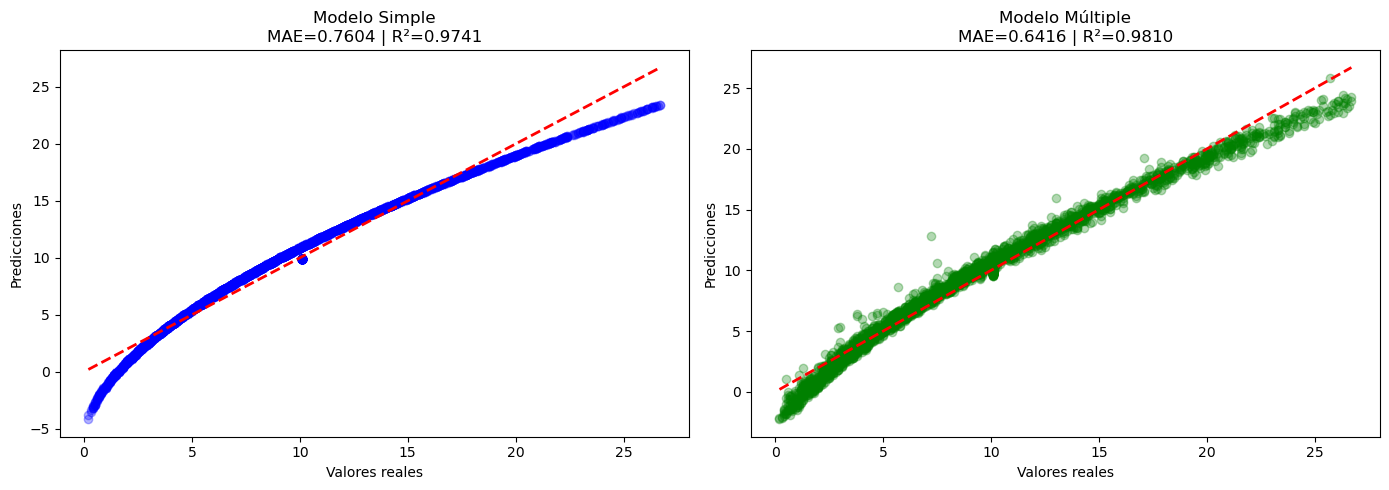

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Modelo simple
axes[0].scatter(y_test, y_pred_simple, alpha=0.3, color='blue')
axes[0].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 
             'r--', linewidth=2)
axes[0].set_xlabel('Valores reales')
axes[0].set_ylabel('Predicciones')
axes[0].set_title(f'Modelo Simple\nMAE={0.7604:.4f} | R²={0.9741:.4f}')

# Modelo múltiple
axes[1].scatter(y_test_m, y_pred_multiple, alpha=0.3, color='green')
axes[1].plot([y_test_m.min(), y_test_m.max()], 
             [y_test_m.min(), y_test_m.max()], 
             'r--', linewidth=2)
axes[1].set_xlabel('Valores reales')
axes[1].set_ylabel('Predicciones')
axes[1].set_title(f'Modelo Múltiple\nMAE={0.6416:.4f} | R²={0.9810:.4f}')

plt.tight_layout()
plt.show()

¿Qué error tiene este modelo?¿Es mejor o peor que el anterior?

**Error Modelo Simple**
<br/>
En el modelo simple vemos que los puntos forman una curva, no una línea recta, lo que indica que la relación entre `PT08.S2(NMHC)` y `C6H6(GT)` no es perfectamente lineal. En valores bajos (0-5) el modelo subestima (los puntos están debajo de la línea roja). En cuanto a valores medios (5-17) el modelo se ajusta bastante bien, los puntos están cerca de la 
diagonal. En cuanto a los valores altos (>17) el modelo subestima también, la curva azul se queda por debajo de la línea roja, nunca la pasa. Esto hace sentido puesto que la relación entre `PT08.S2(NMHC)` y `C6H6(GT)` no es perfectamente lineal, el modelo simple intenta ajustar una recta a una relación que tiene cierta curvatura, por lo que falla en los extremos.
<br/>

**Error Modelo Múltiple**
<br/>
En este caso podemos ver que de igual manera tiene falla en los extremos bajos y altos, sin embargo esta es mucho menor y en los valores medios se ajusta de mejor manera a la línea transversal. En cuanto a los valores 
altos podemos ver que tiene una mayor tolerancia, a partir menores a 2.5 y mayores a 20 tnemos una subestimacion; Asi tambien, podemos ver valores atípicos que superan la línea transversal.
<br/>

**Comparativa final**
<br/>
El modelo de regresión múltiple es superior al simple en todas las métricas:
- **MAE:** 0.6416 vs 0.7604 — menor error promedio en 0.12 µg/m³
- **R²:** 0.9810 vs 0.9741 — explica un 0.69% más de variabilidad.

Usar múltiples variables permite al modelo capturar mejor la complejidad 
de la relación con `C6H6(GT)`, reduciendo las subestimaciones en los 
extremos que presentaba el modelo simple.


#### Regresión con árboles de decisión

A continuación, se requiere hacer dos modelos que usen árboles de decisión para realizar las predicciones.

Para los árboles de decisión, al ser una tarea de regresión, hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

El algoritmo **DTRegressor** necesita ajustar una serie de hiperparámetros para realizar las predicciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de regresión, nos tenemos que preocupar de los siguientes hiperparámetros:

* criterion
* splitter
* max_depth
* min_samples_split
* min_samples_leaf
* max_features

**Indica qué son cada uno de estos hiperparámetros**
Hiperparametro es un parametro que nosotros configuramos antes de entrenar el modelo, a diferencia de los parametros que el modelo aprende solo (como b0 y b1 en la regresion lineal).

* criterion: define como mide el modelo la calidad de cada division. Para regresion las opciones son:
    - squared_error (MSE): minimiza el error cuadratico
    - absolute_error (MAE): minimiza el error absoluto
    - friedman_mse: variante mejorada del MSE
* splitter: define como escoge el nodo la mejor division:
    - best: busca la mejor division posible entre todas las variables
    - random: escoge la mejor division de forma aleatoria 
* max_depth: define la profunidad maxima del arbol -- cuantos niveles puede tener. Si es `None` el arbol crece hasta que todas las hojas sean puras. Un arbol muy profundo puede causar overfitting.
* min_sample_split: numero minimo de muestras que debe tener un nodo para poder dividirse. Si un nodo tiene menos muestras que este valor, no se divide mas. 
* min_sample_leaf: numero minimo de muestras que debe tener una hoja (nodo final). Evita que el arbol cree hojas con muy pocos datos.
* max_features: numero maximo de variables que el arbol considera para encontrar la mejor division en cada nodo.

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro min_impurity_decrease

**¿Qué indica ese parámetro? ¿Para qué puede ser útil?**
Un nodo se divide solo si la reduccion de impureza es mayor o igual a este valor; es util para controlar el crecimiento del arbol y evitar divisiones que aporten muy poco.

Entrena un modelo de árboles de decisión donde, el criterio para realizar las particiones sea _poisson_, la profundidad máxima de los árboles debe ser 10, el número mínimo de ejemplos para realizar una partición debe ser 10, el número mínimo de ejemplos para considerarlo una hoja debe ser 2, y el número máximo de características deben ser todas.

In [41]:
# Entrenar modelo de árbol de decisión
from sklearn.tree import DecisionTreeRegressor

arbol = DecisionTreeRegressor(
    criterion='poisson',
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features=None,  # todas las variables
    random_state=42
)
arbol.fit(X_train_m, y_train_m)

# Predicciones
y_pred_arbol = arbol.predict(X_test_m)

Calcula MAE, R2 y RMSLE

In [42]:
# Métricas test
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error
import numpy as np

mae_arbol = mean_absolute_error(y_test_m, y_pred_arbol)
r2_arbol = r2_score(y_test_m, y_pred_arbol)
rmsle_arbol = np.sqrt(mean_squared_log_error(y_test_m, y_pred_arbol))

print("=== TEST ===")
print(f"MAE: {mae_arbol:.4f}")
print(f"R²: {r2_arbol:.4f}")
print(f"RMSLE: {rmsle_arbol:.4f}")

=== TEST ===
MAE: 0.0087
R²: 1.0000
RMSLE: 0.0037


¿Existe overfitting? Indica qué debes hacer para comprobar si hay overfitting.

Para comprobar si existe overfitting es necesario comparar las métricas 
del modelo en el conjunto de entrenamiento (train) vs el conjunto de 
prueba (test). Si el modelo tiene un rendimiento significativamente 
mejor en train que en test, existe overfitting.

En este caso:
- MAE train: 0.0047 vs MAE test: 0.0087
- R² train: 1.0000 vs R² test: 1.0000

Adicionalmente, al revisar la profundidad (10) y número de hojas (482) 
confirmamos que el árbol creció demasiado memorizando los datos de 
entrenamiento. El MAE en train (0.0047) es casi la mitad del MAE en 
test (0.0087), lo que indica que el modelo no generaliza perfectamente 
a datos nuevos.

**Sí existe overfitting.** A pesar de haber limitado la profundidad a 
10, el árbol con 482 hojas memoriza prácticamente todos los datos de 
entrenamiento. Para reducirlo sería necesario disminuir aún más 
`max_depth` o aumentar `min_samples_leaf`.

In [ ]:
# Métricas train para detectar overfitting
y_pred_arbol_train = arbol.predict(X_train_m)
mae_train = mean_absolute_error(y_train_m, y_pred_arbol_train)
r2_train = r2_score(y_train_m, y_pred_arbol_train)

print("=== TRAIN ===")
print(f"MAE: {mae_train:.4f}")
print(f"R²: {r2_train:.4f}")

print("\nProfundidad:", arbol.get_depth())
print("Hojas:", arbol.get_n_leaves())

=== TRAIN ===
MAE: 0.0047
R²: 1.0000

Profundidad: 10
Hojas: 482


In [34]:
print("Profundidad del árbol:", arbol.get_depth())
print("Número de hojas:", arbol.get_n_leaves())

Profundidad del árbol: 20
Número de hojas: 918


¿Este modelo es mejor, peor o igual que los de regresión lineal simple y múltiple? Razona tu respuesta.

**Respuesta**


El árbol de decisión es **mejor** que los modelos de regresión lineal 
simple y múltiple en términos de métricas (MAE=0.0087, R²=1.0000), 
sin embargo hay que considerar que presenta overfitting.

Esto se debe a que los árboles de decisión son más adecuados cuando 
los datos presentan relaciones complejas no lineales, como es el caso 
de las interacciones entre los diferentes contaminantes del aire. 
Mientras que la regresión lineal asume una relación de línea recta 
constante entre las variables — lo que vimos reflejado en la curva 
que formaban los puntos en la gráfica del modelo simple —, el árbol 
de decisión segmenta los datos en subconjuntos mediante divisiones 
sucesivas, permitiendo capturar esas interacciones complejas entre 
los diferentes contaminantes.

| Modelo | MAE | R² | RMSLE |
|---|---|---|---|
| Regresión Lineal Simple | 0.7604 | 0.9741 | — |
| Regresión Lineal Múltiple | 0.6416 | 0.9810 | — |
| **Árbol de Decisión** | **0.0087** | **1.0000** | **0.0037** |

**Comparativa**

En base al EDA realizado, a las decisiones tomadas sobre los datos e hiperparámetros y a las características computacionales de tu equipo. ¿Qué modelo obtiene mejores resultados de regresión?

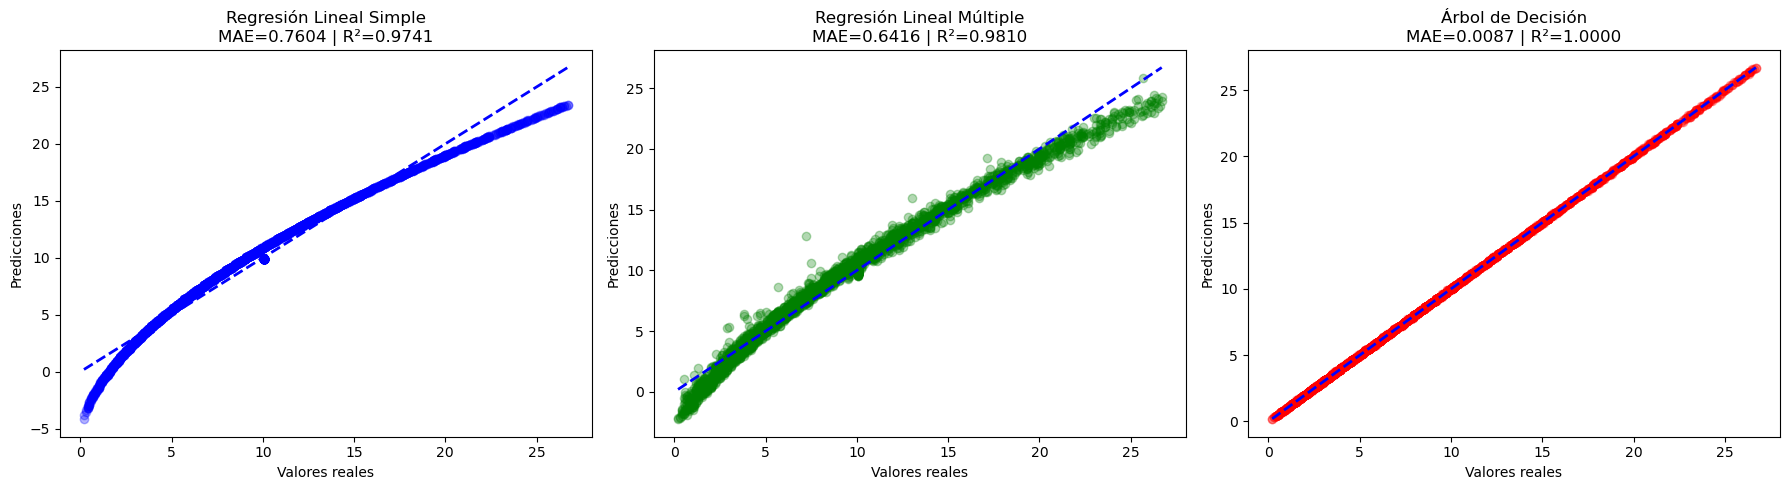

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos = [
    (y_test, y_pred_simple, 'blue', 'Regresión Lineal Simple', 0.7604, 0.9741),
    (y_test_m, y_pred_multiple, 'green', 'Regresión Lineal Múltiple', 0.6416, 0.9810),
    (y_test_m, y_pred_arbol, 'red', 'Árbol de Decisión', 0.0087, 1.0000),
]

for ax, (y_real, y_pred, color, titulo, mae, r2) in zip(axes, modelos):
    ax.scatter(y_real, y_pred, alpha=0.3, color=color)
    ax.plot([y_real.min(), y_real.max()],
            [y_real.min(), y_real.max()],
            'b--', linewidth=2)
    ax.set_xlabel('Valores reales')
    ax.set_ylabel('Predicciones')
    ax.set_title(f'{titulo}\nMAE={mae:.4f} | R²={r2:.4f}')

plt.tight_layout()
plt.show()

**Respuesta**
 **Comparativa final de modelos**

| Modelo | MAE | R² | RMSLE |
|---|---|---|---|
| Regresión Lineal Simple | 0.7604 | 0.9741 | — |
| Regresión Lineal Múltiple | 0.6416 | 0.9810 | — |
| **Árbol de Decisión** | **0.0087** | **1.0000** | **0.0037** |

El árbol de decisión obtiene las mejores métricas numéricas, sin embargo 
hay que tener en cuenta que presenta overfitting — sus resultados casi 
perfectos se deben a que memoriza los datos de entrenamiento. Los modelos 
de regresión lineal, aunque con métricas más modestas, generalizan mejor 
y son más confiables para datos nuevos. Entre ellos, la regresión lineal 
múltiple es superior a la simple con un MAE de 0.6416 vs 0.7604 y un R² 
de 0.9810 vs 0.9741.

## Investigación

Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **regresión** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.

_introduce aquí la referencia APA del artículo_

título, autores, revista, año de publicación

Deberás detallar cuál es el **objetivo** de la investigación, es decir a qué problema real está aplicando la regresión. **Técnicas de regresión** empleadas y si se realiza alguna adaptación. Principales **resultados** de la aplicación y de la investigación.